In [5]:
import sys
from pathlib import Path

from crams import CramsRunner, InjectionParams, PropagationParams

sys.path.append("..")
from mcmc.runner import CramsRunner as McmcCramsRunner

In [6]:
runner = CramsRunner("glauber", "fluka4dragon")
runner_mcmc = McmcCramsRunner(
    build_dir=Path("../build/").resolve(),
    inelastic_model="glauber",
    fragmentation_model="fluka4dragon",
)

In [7]:
def run_subprocess():
    runner_mcmc.run(
        {"d0": 3.0, "delta": 0.50, "ddelta": 0.20, "rb": 300.0, "va": 5.0, "h": 5.0, "phi": 0.60, "xs": -1.0}
        | {"hslope": 4.40, "heslope": 4.35, "slope": 4.30}
        | {"qh": 5.06605e-02, "qhe": 2.54369e-02, "qli": 1.0e-04, "qbe": 0.0, "qb": 0.0}
        | {"qc": 3.98879e-03, "qn": 3.36117e-04, "qo": 7.15129e-03, "qf": 0.0}
        | {"qne": 1.34031e-03, "qna": 0.5e-04, "qmg": 2.38948e-03, "qal": 2.7e-04, "qsi": 2.77911e-03, "qp": 1.0e-04}
        | {"qs": 4.87000e-04, "qcl": 0.0, "qar": 3.0e-04, "qk": 0.0, "qca": 4.0e-04, "qsc": 0.0}
        | {"qti": 0.0, "qv": 0.0, "qcr": 2.5e-04, "qmn": 0.0, "qfe": 6.80000e-03, "qco": 0.0, "qni": 4.0e-04}
    )


def run_wrapped():
    runner.compute(PropagationParams(), InjectionParams.default())

In [8]:
import time

for run_fn, label in ((run_subprocess, "subprocess"), (run_wrapped, "extension")):
    start = time.time()
    evals = 100
    for _ in range(evals):
        run_fn()
    total = time.time() - start
    print(label)
    print(f"total: {total:.2f} sec, per eval: {1000 * total / evals:.2f} msec")

subprocess
total: 5.43 sec, per eval: 54.30 msec
extension
total: 2.94 sec, per eval: 29.37 msec


Text(0, 0.5, '$R^{2.7} \\times J \\; / \\; \\text{GV}^{-1.7} \\; \\text{m}^{-2} \\; \\text{sec}^{-1}$')

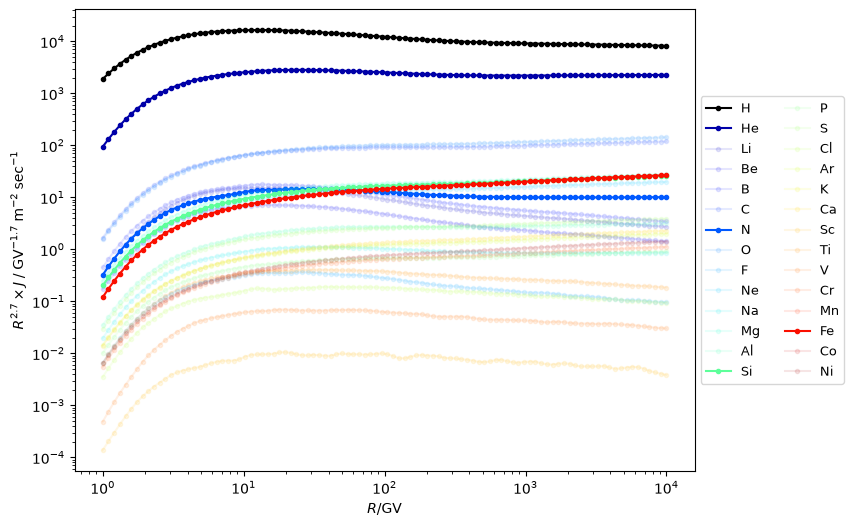

In [9]:
from crams import ELEMENT_NAMES
from matplotlib import pyplot as plt

spectra = runner.compute(PropagationParams(), InjectionParams.default())
fig, ax = plt.subplots(figsize=(8, 6))

R = spectra[:, 0]

cmap = plt.get_cmap("jet")
principal_nuclei = ["H", "He", "N", "Si", "Fe"]
for i, (spec, name) in enumerate(zip(spectra.T[1:, :], ELEMENT_NAMES, strict=True)):
    ax.loglog(
        R,
        R**2.7 * spec,
        ".-",
        label=name,
        color=cmap(i / len(ELEMENT_NAMES)) if name != "H" else "black",
        alpha=0.1 if name not in principal_nuclei else 1.0,
    )

ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), ncol=2, fontsize=9)
ax.set_xlabel("$R / \\text{GV}$")
ax.set_ylabel("$R^{2.7} \\times J \\; / \\; \\text{GV}^{-1.7} \\; \\text{m}^{-2} \\; \\text{sec}^{-1}$")